# Day 2 — DBSCAN & Hierarchical Clustering

Today's notebook will dive deeper into unsupervised learning concepts using a Heart Disease dataset.

In [67]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Data Preparation

In [68]:
df = pd.read_csv("heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [69]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [70]:
df_enc = pd.get_dummies(df, drop_first=True)

In [71]:
x = df_enc.drop('HeartDisease', axis=1)

In [72]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

### DBSCAN

In [73]:
dbscan = DBSCAN(eps=3.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(x_scaled)

n_cluster = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"DBSCAN found {n_cluster} clusters")
print(f"DBSCAN flagged {n_noise} noise points ({n_noise/len(dbscan_labels)*100:.1f}%)")

DBSCAN found 4 clusters
DBSCAN flagged 51 noise points (5.6%)


### Hierarchical Clustering

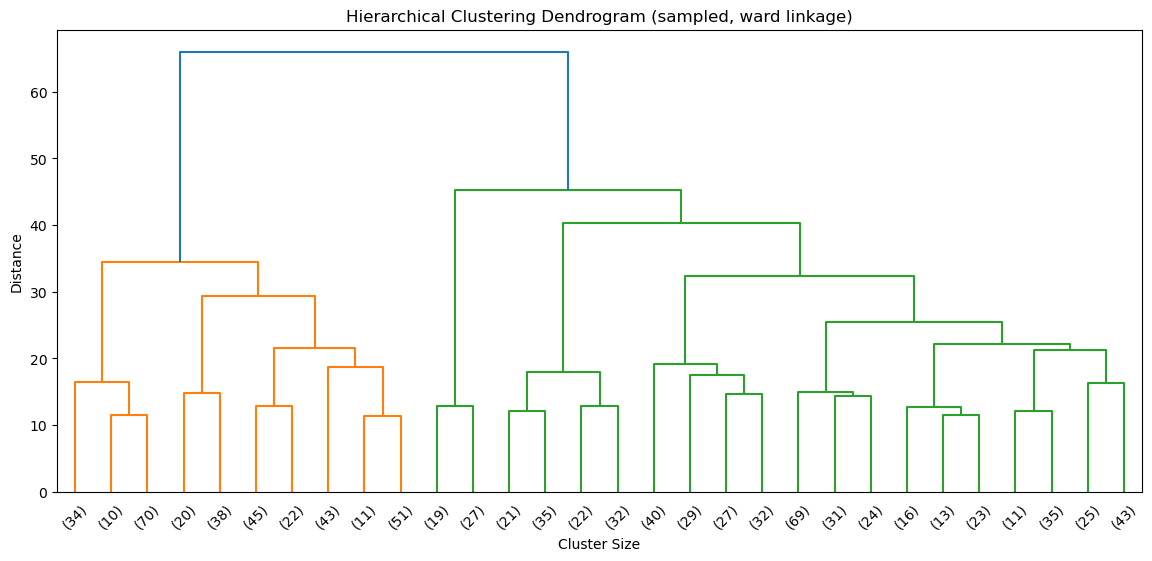

Hierarchical clustering (cut at 60): 2 clusters


In [74]:
sample_idx = np.random.RandomState(42).choice(len(x_scaled), size=918, replace=False)
x_sample= x_scaled[sample_idx]
z = linkage(x_sample, method='ward')

plt.figure(figsize=(14,6))
dendrogram(z, truncate_mode="lastp", p =30)
plt.title("Hierarchical Clustering Dendrogram (sampled, ward linkage)")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()

cut_height = 60
hier_labels_sample = fcluster(z, t=cut_height, criterion="distance")
print(f"Hierarchical clustering (cut at {cut_height}): {len(set(hier_labels_sample))} clusters")

### K-Means

In [75]:
KMeans = KMeans(n_clusters=7, random_state=42, n_init=10)
KMeans_labels = KMeans.fit_predict(x_scaled)
print("K-Means cluster counts:")
print(pd.Series(KMeans_labels).value_counts().sort_index())

K-Means cluster counts:
0    236
1    153
2    124
3    132
4    104
5    123
6     46
Name: count, dtype: int64


### Clustering Comparison

In [76]:
comparison_cluster = pd.DataFrame({
    "Method": ["K-Means", "DBSCAN", "Hierarchical (sampled)"],
    "Clusters Found": [
        len(set(KMeans_labels)),
        n_cluster,
        len(set(hier_labels_sample))
    ],
    "Noise Points": [0, n_noise, 0],
    "Silhouette Score": [
      silhouette_score(x_scaled, KMeans_labels),
      silhouette_score(x_scaled, dbscan_labels) if n_cluster>1 else None,
        silhouette_score(x_sample, hier_labels_sample) if len(set(hier_labels_sample))>1 else None
    ]
})

print(comparison_cluster)

                   Method  Clusters Found  Noise Points  Silhouette Score
0                 K-Means               7             0          0.159786
1                  DBSCAN               4            51          0.160152
2  Hierarchical (sampled)               2             0          0.158828


### Clustering Comparison Takeaways

Three clustering methods were applied to the scaled numeric features - excluding the target- to explore wether natural patient grouping exists in the data independent of the HeartDisease label.

**K-Means:** k=7, produced 7 roughly evenly-sized clusters, but assumes round, similarly sized groups.
**DBSCAN:** eps=3.0, min_samples=5, found 4 clusters and flagged 5% of the points as noise.
**Heirarchical Clustering:** (ward linkage, sampled): the dendrogram revealed no strongly seperated branches, suggesting continuous rather than distinctly clustered patient profiles cutting at height=60 produced 2 clusters.

**conclusion:** K-Mean appears to be the most practical clustering method for this dataset, although a low silhouette score indicates that the clusters are weakly seperated. Overall the silhouette scores are low accrosss all 3 methods indicating that the dataset does not have strongly seperated natural patient groups.